In [1]:
!pip -q install keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 18.6 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_cv

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from google.colab import drive

# Keeping the seed fixed so I get the same splits and similar results each time
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("KerasCV version:", keras_cv.__version__)

TensorFlow version: 2.19.0
KerasCV version: 0.9.0


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Using the same synthetic image dataset from the student wellness dataset
base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/images"
train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))
print("Class folders:", os.listdir(train_dir))

Train exists: True
Test exists: True
Class folders: ['high_risk', 'moderate_risk', 'low_risk', 'critical_risk']


In [5]:
# Loading the image dataset for TensorFlow
image_size = (64, 64)
batch_size = 32

tf_train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=image_size,
    batch_size=batch_size
)

tf_val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=image_size,
    batch_size=batch_size
)

tf_test_ds = image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = tf_train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
tf_train_ds = tf_train_ds.prefetch(AUTOTUNE)
tf_val_ds = tf_val_ds.prefetch(AUTOTUNE)
tf_test_ds = tf_test_ds.prefetch(AUTOTUNE)

print("Class names:", class_names)

Found 240 files belonging to 4 classes.
Using 192 files for training.
Found 240 files belonging to 4 classes.
Using 48 files for validation.
Found 80 files belonging to 4 classes.
Class names: ['critical_risk', 'high_risk', 'low_risk', 'moderate_risk']


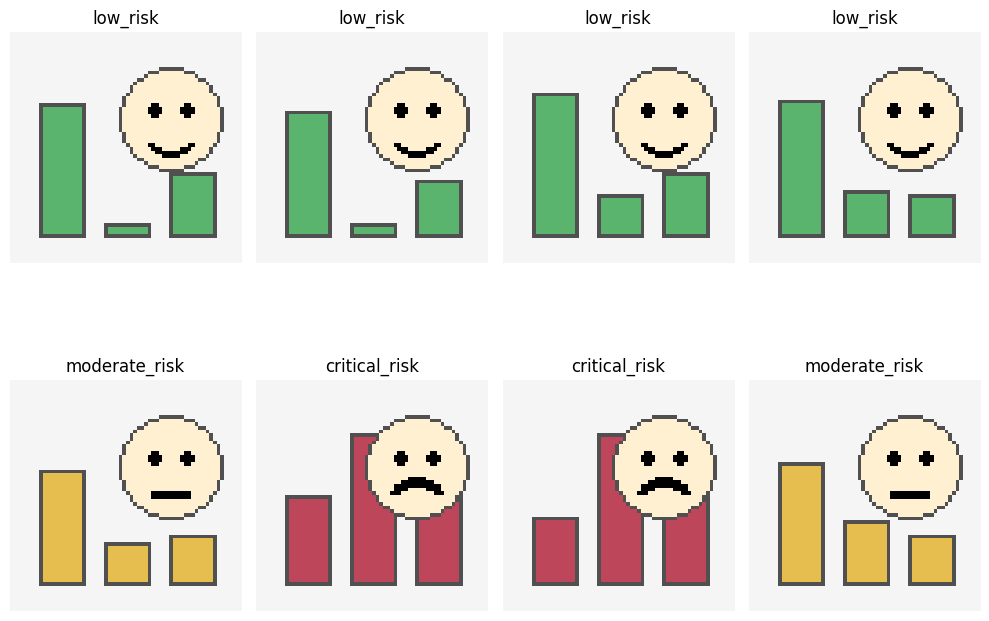

In [6]:
# Showing a few original images from the dataset
plt.figure(figsize=(10, 8))

for images, labels in tf_train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# This is a simple baseline model without augmentation
def build_image_model():
    model = keras.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [8]:
# First I train a baseline model without any augmentation
baseline_model = build_image_model()

history_baseline = baseline_model.fit(
    tf_train_ds,
    validation_data=tf_val_ds,
    epochs=10,
    verbose=0
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(tf_test_ds, verbose=0)
print("Baseline Test Accuracy:", round(baseline_test_acc, 4))

Baseline Test Accuracy: 1.0


In [9]:
# These are standard Keras augmentation layers for images
keras_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

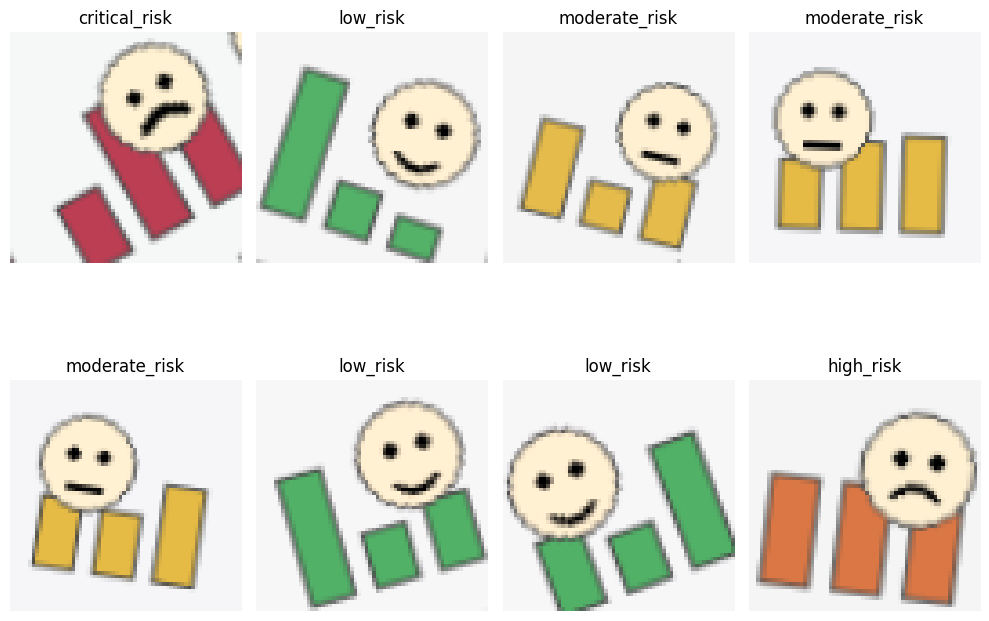

In [10]:
# Visualizing what the standard Keras augmentation looks like
for images, labels in tf_train_ds.take(1):
    plt.figure(figsize=(10, 8))
    for i in range(8):
        augmented_image = keras_augmentation(tf.expand_dims(images[i], axis=0), training=True)
        plt.subplot(2, 4, i + 1)
        plt.imshow(tf.cast(augmented_image[0], tf.uint8).numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [11]:
# Building a model that applies Keras augmentation inside the pipeline
def build_model_with_keras_aug():
    model = keras.Sequential([
        layers.Input(shape=(64, 64, 3)),
        keras_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [12]:
# Now I train the model with built-in Keras augmentation
keras_aug_model = build_model_with_keras_aug()

history_keras_aug = keras_aug_model.fit(
    tf_train_ds,
    validation_data=tf_val_ds,
    epochs=10,
    verbose=0
)

keras_aug_test_loss, keras_aug_test_acc = keras_aug_model.evaluate(tf_test_ds, verbose=0)
print("Keras Augmentation Test Accuracy:", round(keras_aug_test_acc, 4))

Keras Augmentation Test Accuracy: 1.0


In [13]:
# Trying a KerasCV augmentation pipeline too
keras_cv_augmentation = keras.Sequential([
    keras_cv.layers.RandomFlip(mode="horizontal"),
    keras_cv.layers.RandomRotation(factor=0.1),
    keras_cv.layers.RandomShear(x_factor=0.1, y_factor=0.1),
    keras_cv.layers.RandomColorDegeneration(factor=0.2)
])

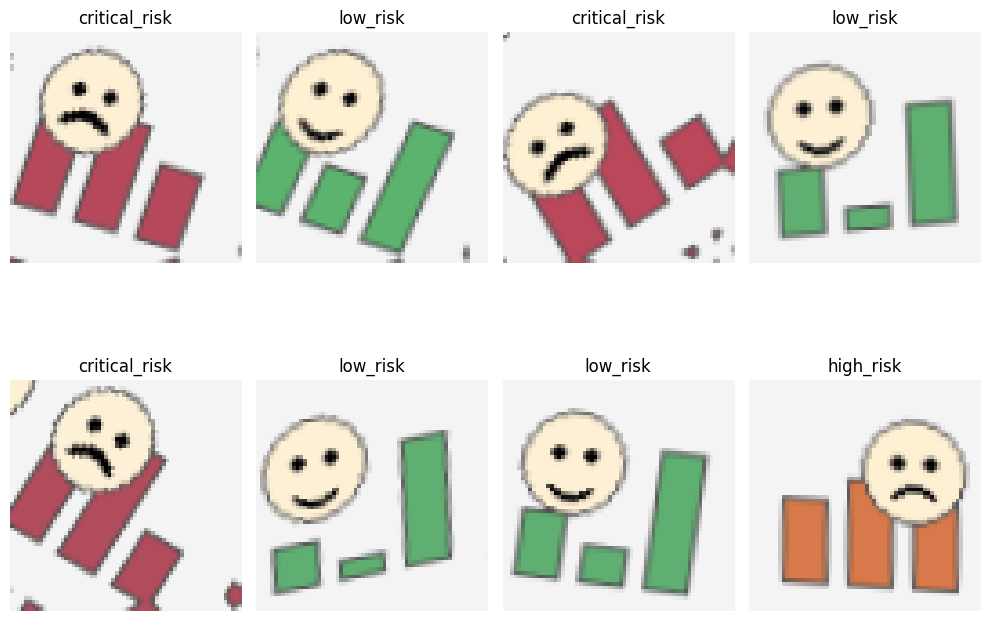

In [14]:
# Visualizing a few KerasCV-augmented samples
for images, labels in tf_train_ds.take(1):
    plt.figure(figsize=(10, 8))
    for i in range(8):
        augmented_image = keras_cv_augmentation(tf.expand_dims(images[i], axis=0), training=True)
        plt.subplot(2, 4, i + 1)
        plt.imshow(tf.cast(augmented_image[0], tf.uint8).numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [17]:
# Building a model that uses the KerasCV augmentation pipeline
def build_model_with_kerascv_aug():
    model = keras.Sequential([
        layers.Input(shape=(64, 64, 3)),
        keras_cv_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [18]:
# Training the model with KerasCV augmentation
kerascv_aug_model = build_model_with_kerascv_aug()

history_kerascv_aug = kerascv_aug_model.fit(
    tf_train_ds,
    validation_data=tf_val_ds,
    epochs=10,
    verbose=0
)

kerascv_aug_test_loss, kerascv_aug_test_acc = kerascv_aug_model.evaluate(tf_test_ds, verbose=0)
print("KerasCV Augmentation Test Accuracy:", round(kerascv_aug_test_acc, 4))

KerasCV Augmentation Test Accuracy: 0.625


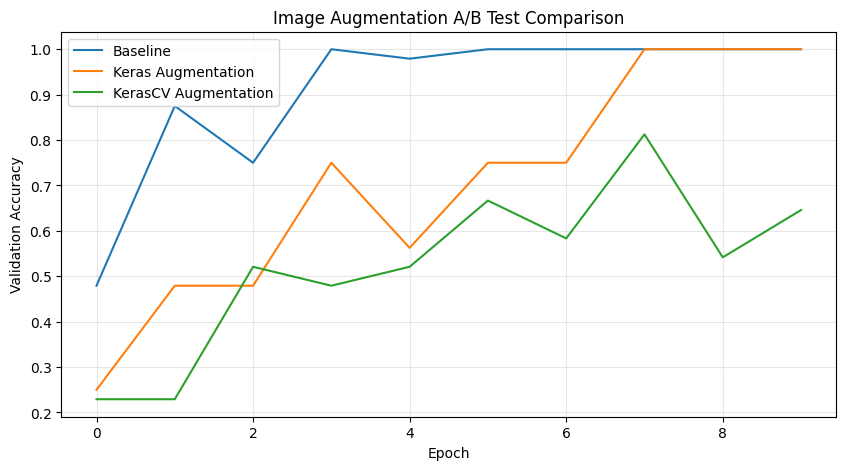

In [19]:
# Comparing the validation accuracy curves for all three image experiments
plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_keras_aug.history["val_accuracy"], label="Keras Augmentation")
plt.plot(history_kerascv_aug.history["val_accuracy"], label="KerasCV Augmentation")
plt.title("Image Augmentation A/B Test Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

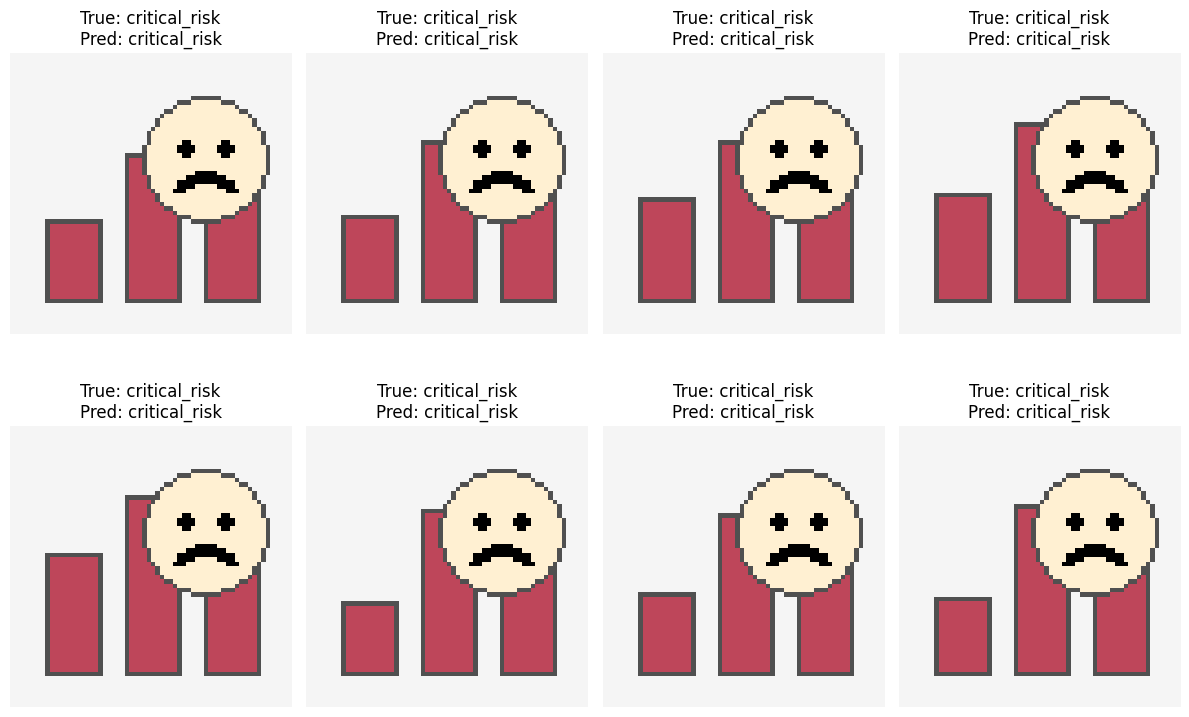

In [20]:
# Looking at a few predictions from the best-performing model
best_model = kerascv_aug_model if kerascv_aug_test_acc >= keras_aug_test_acc else keras_aug_model

for images, labels in tf_test_ds.take(1):
    predictions = best_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 8))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_classes[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [21]:
# Final summary so I can clearly talk about the results in the video
print("Image Augmentation Results")
print("-" * 45)
print(f"Baseline Model         : {baseline_test_acc:.4f}")
print(f"Keras Augmentation     : {keras_aug_test_acc:.4f}")
print(f"KerasCV Augmentation   : {kerascv_aug_test_acc:.4f}")

Image Augmentation Results
---------------------------------------------
Baseline Model         : 1.0000
Keras Augmentation     : 1.0000
KerasCV Augmentation   : 0.6250


### Final Observation

In this notebook, I compared image classification without augmentation against two augmentation-based pipelines: standard Keras augmentation layers and KerasCV augmentation layers. The goal was to see whether stronger augmentation helps the model generalize better on the synthetic student wellness image dataset. This notebook helped me understand how augmentation can act like a regularization technique by exposing the model to more varied versions of the training images.